In [54]:
### TASK-7
import pandas as pd

from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/titanic_cleaned.csv")
df


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
885,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
886,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
887,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [55]:
### Features and Target
X=df.drop("survived",axis=1)
Y=df["survived"]

In [56]:
### Stratified Train-Test Split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)
print("Training set:",X_train.shape)
print("Testing set:",X_test.shape)

print("\nTrain Class Distribution")
print(Y_train.value_counts(normalize=True))

print("\nTest Class Distribution")
print(Y_test.value_counts(normalize=True))

Training set: (711, 13)
Testing set: (178, 13)

Train Class Distribution
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Test Class Distribution
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


Justification:
A stratified train-test split preserves same proportion of survived and non-survived passengers in both the training and testing datasets.This ensures the model learns from a representative sample and provides a fair evaluat

In [57]:
### TASK-8
### Import libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import  SimpleImputer
from sklearn.preprocessing import  OneHotEncoder,StandardScaler

In [58]:
### Select Features
features=["pclass","sex","age","sibsp","parch","fare","embarked"]

X=df[features]
y=df["survived"]


In [59]:
### Split the Data
from sklearn.model_selection import  train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)


In [60]:
### Create Preprocessing Pipeline
numaric_features=["age","fare","sibsp","parch","pclass"]
categorical_features=["sex","embarked"]

numeric_transformer=Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_transformer=Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

preprocessor=ColumnTransformer([("num",numeric_transformer,numaric_features),("cat",categorical_transformer,categorical_features)])


In [61]:
### Fit on Training data Only
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)


print("Training Shape:",X_train_processed.shape)
print("Tesing Shape:",X_test_processed.shape)

Training Shape: (711, 10)
Tesing Shape: (178, 10)


Written Explanation:
Missing values in numerical columns were filled using the median.Missing values in categorical columns were filled using the frequent value.Categorical variables(sex and embarked) were one-hot encoded,and numerical features were stanarddized using Standardscaler.The preprocessing pipeline was fitted only on the  training data and then applied to the test data to avoid data leakage.

In [106]:
### TASK-9
from sklearn.linear_model import  LogisticRegression
from sklearn.tree import  DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


In [107]:
### LogisticRegression
lr=LogisticRegression(random_state=42)
lr.fit(X_train_processed,Y_train)

LogisticRegression(random_state=42)

In [109]:
### Decision Tree
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train_processed,Y_train)

DecisionTreeClassifier(random_state=42)

In [110]:
### Random Forest
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train_processed,Y_train)

print("All three models trained successfully!")

All three models trained successfully!


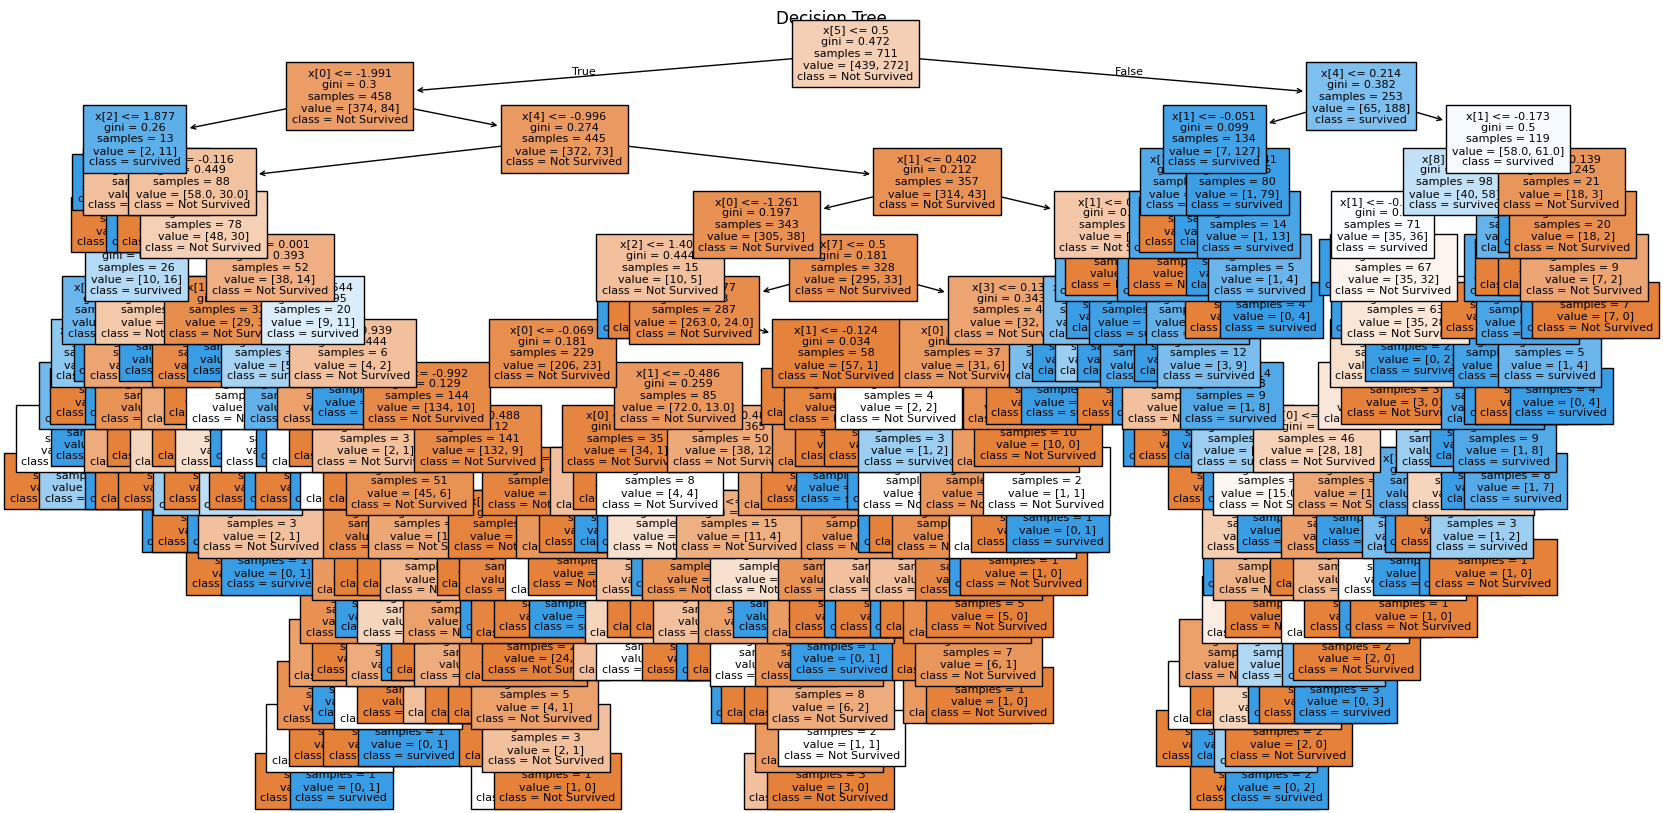

In [111]:
### Plot Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt,filled=True,class_names=["Not Survived","survived"],fontsize=8)
plt.title("Decision Tree")
plt.show()

In [112]:
### TASK-10
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    print("\n", "="*40)
    print(name)
    print("="*40)
    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(Y_test, y_pred),
        "Precision": precision_score(Y_test, y_pred),
        "Recall": recall_score(Y_test, y_pred),
        "F1 Score": f1_score(Y_test, y_pred),
        "ROC AUC": roc_auc_score(Y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

print("\nModel Comparison Table")
print(comparison_df)


Logistic Regression
Confusion Matrix:
[[97 13]
 [21 47]]

Decision Tree
Confusion Matrix:
[[88 22]
 [19 49]]

Random Forest
Confusion Matrix:
[[96 14]
 [18 50]]

Model Comparison Table
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.808989   0.783333  0.691176  0.734375  0.860963
1        Decision Tree  0.769663   0.690141  0.720588  0.705036  0.754144
2        Random Forest  0.820225   0.781250  0.735294  0.757576  0.821457


In [68]:
!pip install imbalanced-learn

In [69]:
### TASK-11
from sklearn.linear_model import  LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score
from imblearn.over_sampling import SMOTE
import pandas as pd
result=[]




In [113]:
### Baseline
baseline=LogisticRegression(random_state=42)
baseline.fit(X_train_processed,Y_train)
pred=baseline.predict(X_test_processed)

results.append({"Method":"Baseline",
                "Precision":precision_score(Y_test,pred),
                "Recall":recall_score(Y_test,pred),
                "F1 Score":f1_score(Y_test,pred)
                })

In [115]:
### Class Weight Balanced
balanced = LogisticRegression(class_weight="balanced", random_state=42)
balanced.fit(X_train_processed, Y_train)
pred = balanced.predict(X_test_processed)

results.append({
    "Method": "Class Weight",
    "Precision": precision_score(Y_test, pred),
    "Recall": recall_score(Y_test, pred),
    "F1 Score": f1_score(Y_test, pred)
})

In [116]:
### SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, Y_train)

smote_model = LogisticRegression(random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
pred = smote_model.predict(X_test_processed)

results.append({
    "Method": "SMOTE",
    "Precision": precision_score(Y_test, pred),
    "Recall": recall_score(Y_test, pred),
    "F1 Score": f1_score(Y_test, pred)
})

comparison=pd.DataFrame(results)

task11 = comparison[comparison["Method"].notna()]

best = task11.loc[task11["F1 Score"].idxmax()]

print("\nConclusion:")
print(f"{best['Method']} gives the best F1 Score ({best['F1 Score']:.3f}).")




Conclusion:
SMOTE gives the best F1 Score (0.735).


In [117]:
#### TASK-12
from sklearn.ensemble import  RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [118]:
### Parameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [75]:
### Random Forest With OOB Score
rf=RandomForestClassifier(random_state=42,
                          oob_score=True,
                          bootstrap=True)


In [76]:
### Grid Search
grid_search=GridSearchCV(estimator=rf,
                         param_grid=param_grid,
                         cv=5,
                         scoring="f1",
                        n_jobs=-1 )

In [77]:
### Train on  training data only
grid_search.fit(X_train_processed,Y_train)


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(oob_score=True, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [78]:
### Best model
best_rf=grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(grid_search.best_score_)

print("\nOOB Score:")
print(best_rf.oob_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation F1 Score:
0.7484352323437611

OOB Score:
0.8045007032348804


In [79]:
#### Evaluate the tuned model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = best_rf.predict(X_test_processed)

print("\nAccuracy :", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))
print("Recall   :", recall_score(Y_test, y_pred))
print("F1 Score :", f1_score(Y_test, y_pred))
print("ROC AUC  :", roc_auc_score(Y_test, best_rf.predict_proba(X_test_processed)[:,1]))


Accuracy : 0.8370786516853933
Precision: 0.8823529411764706
Recall   : 0.6617647058823529
F1 Score : 0.7563025210084033
ROC AUC  : 0.8314839572192514


In [80]:
#### TASK-13
### Multiple Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import  train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
import matplotlib.pyplot as plt


In [81]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [82]:
#### Features and Target
X_reg=df.drop("fare",axis=1)
Y_reg=df["fare"]

In [83]:
# Numerical columns
num_cols = ["age", "sibsp", "parch"]

# Categorical columns
cat_cols = ["sex", "embarked", "class", "who", "adult_male", "embark_town", "alive", "alone", "pclass", "survived"]

In [84]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_reg = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [85]:
#### Train test split
X_train_reg,X_test_reg,Y_train_reg,Y_test_reg=train_test_split(X_reg,Y_reg,test_size=0.2,random_state=42,)


In [87]:
### Preprocessor
X_train_processed=preprocessor_reg.fit_transform(X_train_reg)
X_test_processed=preprocessor_reg.transform(X_test_reg)

In [93]:
### Train model
lr=LinearRegression()
lr.fit(X_train_processed,Y_train_reg)



LinearRegression()

In [94]:
### Prediction
y_pred=lr.predict(X_test_processed)

In [96]:
### Metrics
mae=mean_absolute_error(Y_test_reg,y_pred)
rmse=np.sqrt(mean_absolute_error(Y_test_reg,y_pred))
r2=r2_score(Y_test_reg,y_pred)

In [97]:
### Adjusted R2
n=len(Y_test_reg)
p=X_test_processed.shape[1]
adj_r2=1-(1-r2)*(n-1)/(n-p-1)

print("MAE:",round(mae,3))
print("RMSE:",round(rmse,3))
print("R2:",round(r2,3))
print("Adjusted R2:",round(adj_r2,3))

MAE: 18.374
RMSE: 4.286
R2: 0.361
Adjusted R2: 0.241


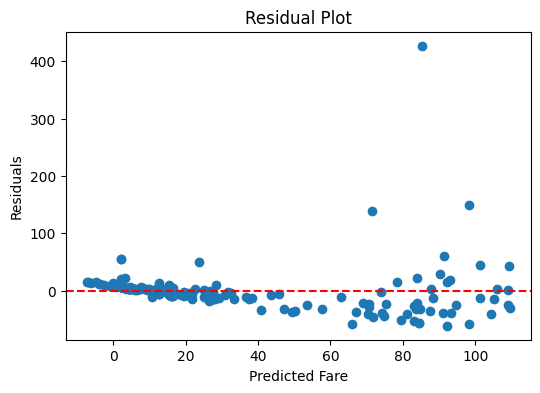

In [98]:
### Residual Plot
residuals=Y_test_reg-y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [99]:
#### Written Conclusioin
if np.std(residuals)>0:
  print("\nConclusion:")
  print("Residuals appear randomly scattered around Zero.")
  print("No strong evidence of heteroscedasticity")


Conclusion:
Residuals appear randomly scattered around Zero.
No strong evidence of heteroscedasticity


Conclusion:
The residual plot shows that the spread of residuals increases as the predicted fare increases.This indicates heteroscedasticity,meaning the variance of errors is not constant.Therefore,the assumptions of linear regression are not fully satisified,and the model predicts low fares better than high fares.

In [104]:
### Recreate classification processed data
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)

In [119]:
### TASK-14
### Model comparison

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "Multiple Linear Regression"
    ],
    "Accuracy": [
        accuracy_score(Y_test, dt.predict(X_test_processed)),
        accuracy_score(Y_test, rf.predict(X_test_processed)),
        accuracy_score(Y_test, lr.predict(X_test_processed)),
        "-"
    ],
    "Precision": [
        precision_score(Y_test, dt.predict(X_test_processed)),
        precision_score(Y_test, rf.predict(X_test_processed)),
        precision_score(Y_test, lr.predict(X_test_processed)),
        "-"
    ],
    "Recall": [
        recall_score(Y_test, dt.predict(X_test_processed)),
        recall_score(Y_test, rf.predict(X_test_processed)),
        recall_score(Y_test, lr.predict(X_test_processed)),
        "-"
    ],
    "F1 Score": [
        f1_score(Y_test, dt.predict(X_test_processed)),
        f1_score(Y_test, rf.predict(X_test_processed)),
        f1_score(Y_test, lr.predict(X_test_processed)),
        "-"
    ],
    "ROC AUC": [
        roc_auc_score(Y_test, dt.predict_proba(X_test_processed)[:,1]),
        roc_auc_score(Y_test, rf.predict_proba(X_test_processed)[:,1]),
        roc_auc_score(Y_test, lr.predict_proba(X_test_processed)[:,1]),
        "-"
    ],
    "MAE": [
        "-",
        "-",
        "-",
        round(mae,3)
    ],
    "RMSE": [
        "-",
        "-",
        "-",
        round(rmse,3)
    ],
    "R2": [
        "-",
        "-",
        "-",
        round(r2,3)
    ],
    "Adjusted R2": [
        "-",
        "-",
        "-",
        round(adj_r2,3)
    ]
})

print(comparison)

                        Model  Accuracy Precision    Recall  F1 Score  \
0               Decision Tree  0.769663  0.690141  0.720588  0.705036   
1               Random Forest  0.820225   0.78125  0.735294  0.757576   
2         Logistic Regression  0.808989  0.783333  0.691176  0.734375   
3  Multiple Linear Regression         -         -         -         -   

    ROC AUC     MAE   RMSE     R2 Adjusted R2  
0  0.754144       -      -      -           -  
1  0.821457       -      -      -           -  
2  0.860963       -      -      -           -  
3         -  18.374  4.286  0.361       0.241  


Final Recommendation:

Among the three classification models, Random Forest performed the best because it achieved the highest overall classification metrics, including Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Therefore, Random Forest is the recommended model for predicting passenger survival.

For the regression task, Multiple Linear Regression achieved an R² score of 0.361 with an Adjusted R² of 0.241. The residual plot shows heteroscedasticity, indicating that prediction errors increase for higher fare values. Although the regression model captures some relationship between the features and fare, its performance is moderate and can be improved using more advanced regression models.\

In [120]:
# TASK 15 - Save the trained model

import joblib

# Save the preprocessing pipeline
joblib.dump(preprocessor, "preprocessor.pkl")

# Save the best classification model
joblib.dump(rf, "random_forest_model.pkl")

print("Preprocessor saved as preprocessor.pkl")
print("Random Forest model saved as random_forest_model.pkl")

Preprocessor saved as preprocessor.pkl
Random Forest model saved as random_forest_model.pkl


In [121]:
from sklearn.pipeline import Pipeline
import joblib

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

joblib.dump(final_pipeline, "titanic_pipeline.pkl")

print("Pipeline saved successfully as titanic_pipeline.pkl")

Pipeline saved successfully as titanic_pipeline.pkl
